In [119]:
# Breast Cancer Wisconsin Dataset
import pandas as pd

data = pd.read_csv("data.csv")

In [72]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [73]:
data.shape

(569, 33)

In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [75]:
data['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


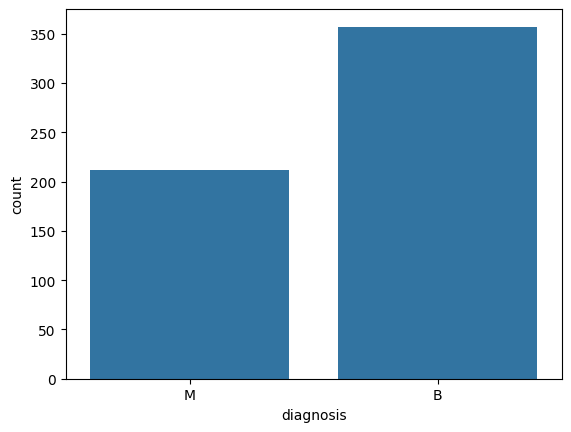

In [124]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='diagnosis', data=data)
plt.show()

The dataset is imbalanced because the number of benign samples is larger than malignant samples

**Data Preprocessing**

In [77]:
df = data.copy()

In [78]:
df = df.drop(columns=['id', 'Unnamed: 32'])

In [79]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [80]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [121]:
df['diagnosis'].value_counts()


,count
diagnosis,
0,357
1,212


In [83]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.09706398e+00, -2.07333501e+00,  1.26993369e+00,
         9.84374905e-01,  1.56846633e+00,  3.28351467e+00,
         2.65287398e+00,  2.53247522e+00,  2.21751501e+00,
         2.25574689e+00,  2.48973393e+00, -5.65265059e-01,
         2.83303087e+00,  2.48757756e+00, -2.14001647e-01,
         1.31686157e+00,  7.24026158e-01,  6.60819941e-01,
         1.14875667e+00,  9.07083081e-01,  1.88668963e+00,
        -1.35929347e+00,  2.30360062e+00,  2.00123749e+00,
         1.30768627e+00,  2.61666502e+00,  2.10952635e+00,
         2.29607613e+00,  2.75062224e+00,  1.93701461e+00],
       [ 1.82982061e+00, -3.53632408e-01,  1.68595471e+00,
         1.90870825e+00, -8.26962447e-01, -4.87071673e-01,
        -2.38458552e-02,  5.48144156e-01,  1.39236330e-03,
        -8.68652457e-01,  4.99254601e-01, -8.76243603e-01,
         2.63326966e-01,  7.42401948e-01, -6.05350847e-01,
        -6.92926270e-01, -4.40780058e-01,  2.60162067e-01,
        -8.05450380e-01, -9.94437403e-02,  1.80592744e+

**Prepare minority data**

The minority class (malignant tumors) was extracted separately in order to train GAN models and generate additional synthetic samples for balancing the dataset.

In [125]:

minority_data = X_scaled[y == 1]

print(minority_data.shape)

(212, 30)


In [86]:
import tensorflow as tf

batch_size = 32

dataset = tf.data.Dataset.from_tensor_slices(minority_data.astype('float32'))
dataset = dataset.shuffle(buffer_size=212).batch(batch_size)

In [87]:
tf.random.set_seed(42)
np.random.seed(42)

# **Vanilla GAN**

Building Vanilla GAN

A Vanilla Generative Adversarial Network (GAN) was implemented to generate synthetic malignant samples. The GAN consists of two neural networks:
- Generator: creates synthetic samples
- Discriminator: distinguishes between real and fake samples


In [88]:
from tensorflow.keras import layers, models

latent_dim = 16
data_dim = minority_data.shape[1]

In [89]:
def build_generator():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_dim=latent_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(data_dim, activation='linear')
    ])
    return model

In [90]:
def build_discriminator():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_dim=data_dim),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [91]:
generator = build_generator()
discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
generator.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,278 (51.87 KB)

 Trainable params: 13,278 (51.87 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
discriminator.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Training Vanilla GAN

The Vanilla GAN was trained using adversarial learning. During training, the generator learns to create realistic samples while the discriminator learns to detect fake samples.

In [94]:
loss_fn = tf.keras.losses.BinaryCrossentropy()

gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002)

epochs = 1000

g_losses = []
d_losses = []

for epoch in range(epochs):
    for real_samples in dataset:
        batch_size_current = tf.shape(real_samples)[0]


        noise = tf.random.normal([batch_size_current, latent_dim])
        fake_samples = generator(noise)


        with tf.GradientTape() as disc_tape:
            real_output = discriminator(real_samples)
            fake_output = discriminator(fake_samples)

            disc_loss_real = loss_fn(tf.ones_like(real_output), real_output)
            disc_loss_fake = loss_fn(tf.zeros_like(fake_output), fake_output)
            disc_loss = disc_loss_real + disc_loss_fake

        gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
        disc_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))


        noise = tf.random.normal([batch_size_current, latent_dim])

        with tf.GradientTape() as gen_tape:
            generated_samples = generator(noise)
            fake_output = discriminator(generated_samples)
            gen_loss = loss_fn(tf.ones_like(fake_output), fake_output)

        gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
        gen_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))

    g_losses.append(gen_loss.numpy())
    d_losses.append(disc_loss.numpy())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Generator Loss: {gen_loss.numpy():.4f}, Discriminator Loss: {disc_loss.numpy():.4f}")

Epoch 100, Generator Loss: 1.1624, Discriminator Loss: 1.1273
Epoch 200, Generator Loss: 1.2457, Discriminator Loss: 1.1836
Epoch 300, Generator Loss: 0.9682, Discriminator Loss: 1.2977
Epoch 400, Generator Loss: 1.0031, Discriminator Loss: 1.0975
Epoch 500, Generator Loss: 0.7706, Discriminator Loss: 1.1361
Epoch 600, Generator Loss: 1.0285, Discriminator Loss: 1.0186
Epoch 700, Generator Loss: 0.8139, Discriminator Loss: 1.2564
Epoch 800, Generator Loss: 0.9489, Discriminator Loss: 1.1896
Epoch 900, Generator Loss: 0.9600, Discriminator Loss: 1.2201
Epoch 1000, Generator Loss: 0.8765, Discriminator Loss: 1.1141


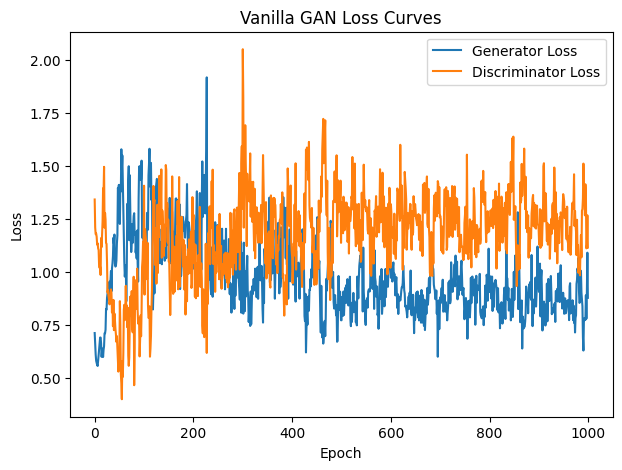

In [95]:
plt.figure(figsize=(7,5))

plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla GAN Loss Curves")

plt.legend()
plt.show()

**Generating Synthetic Samples**

After training the GAN, synthetic malignant samples were generated to balance the dataset and reduce the class imbalance problem

In [96]:
num_samples_to_generate = 357 - 212

noise = tf.random.normal([num_samples_to_generate, latent_dim])
synthetic_minority = generator(noise).numpy()

print(synthetic_minority.shape)

(145, 30)


In [97]:
import numpy as np

# Original minority labels
synthetic_labels = np.ones(num_samples_to_generate)

# Combine original data with synthetic data
X_balanced = np.vstack([X_scaled, synthetic_minority])
y_balanced = np.concatenate([y, synthetic_labels])

print(X_balanced.shape)
print(y_balanced.shape)

(714, 30)
(714,)


In [98]:
pd.Series(y_balanced).value_counts()

,count
1.0,357
0.0,357


**Classification**

In [99]:
from sklearn.model_selection import train_test_split

# Original data split
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Balanced data split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

print(X_train_orig.shape)
print(X_train_bal.shape)

(455, 30)
(571, 30)


In [100]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Classifier on original imbalanced data
clf_orig = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
clf_orig.fit(X_train_orig, y_train_orig)

y_pred_orig = clf_orig.predict(X_test_orig)

print("Original Imbalanced Dataset Results")
print(classification_report(y_test_orig, y_pred_orig))

Original Imbalanced Dataset Results
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [101]:
# Classifier on balanced data using Vanilla GAN
clf_bal = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
clf_bal.fit(X_train_bal, y_train_bal)

y_pred_bal = clf_bal.predict(X_test_bal)

print("Balanced Dataset with Vanilla GAN Results")
print(classification_report(y_test_bal, y_pred_bal))

Balanced Dataset with Vanilla GAN Results
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98        69
         1.0       0.99      0.97      0.98        74

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



# **WGAN**

**Building and Training WGAN**

A Wasserstein GAN (WGAN) was implemented as an improved GAN variant. WGAN provides more stable training and better synthetic sample generation compared to Vanilla GAN

In [102]:
latent_dim = 16
data_dim = minority_data.shape[1]  # 30

def build_wgan_generator():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_dim=latent_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(data_dim, activation='linear')
    ])
    return model

def build_wgan_critic():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_dim=data_dim),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)  # no sigmoid in WGAN
    ])
    return model

wgan_generator = build_wgan_generator()
critic = build_wgan_critic()

wgan_generator.summary()
critic.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,278 (51.87 KB)

 Trainable params: 13,278 (51.87 KB)

...

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
# WGAN training

wgan_gen_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.00005)
critic_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.00005)

epochs = 1000
n_critic = 5
clip_value = 0.01

wgan_g_losses = []
critic_losses = []

for epoch in range(epochs):
    for real_samples in dataset:
        batch_size_current = tf.shape(real_samples)[0]

        # Train critic multiple times
        for _ in range(n_critic):
            noise = tf.random.normal([batch_size_current, latent_dim])

            with tf.GradientTape() as critic_tape:
                fake_samples = wgan_generator(noise)

                real_score = critic(real_samples)
                fake_score = critic(fake_samples)

                critic_loss = tf.reduce_mean(fake_score) - tf.reduce_mean(real_score)

            gradients_critic = critic_tape.gradient(
                critic_loss, critic.trainable_variables
            )

            critic_optimizer.apply_gradients(
                zip(gradients_critic, critic.trainable_variables)
            )

            # Weight clipping
            for weight in critic.trainable_variables:
                weight.assign(tf.clip_by_value(weight, -clip_value, clip_value))

        # Train generator
        noise = tf.random.normal([batch_size_current, latent_dim])

        with tf.GradientTape() as gen_tape:
            generated_samples = wgan_generator(noise)
            fake_score = critic(generated_samples)
            wgan_gen_loss = -tf.reduce_mean(fake_score)

        gradients_gen = gen_tape.gradient(
            wgan_gen_loss, wgan_generator.trainable_variables
        )

        wgan_gen_optimizer.apply_gradients(
            zip(gradients_gen, wgan_generator.trainable_variables)
        )

    # Save losses after each epoch
    wgan_g_losses.append(wgan_gen_loss.numpy())
    critic_losses.append(critic_loss.numpy())

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch+1}, WGAN Generator Loss: {wgan_gen_loss.numpy():.4f}, Critic Loss: {critic_loss.numpy():.4f}"
        )

Epoch 100, WGAN Generator Loss: 0.0066, Critic Loss: -0.0122
Epoch 200, WGAN Generator Loss: 0.0013, Critic Loss: -0.0131
Epoch 300, WGAN Generator Loss: -0.0002, Critic Loss: -0.0095
Epoch 400, WGAN Generator Loss: -0.0030, Critic Loss: -0.0066
Epoch 500, WGAN Generator Loss: 0.0026, Critic Loss: -0.0085
Epoch 600, WGAN Generator Loss: 0.0004, Critic Loss: -0.0047
Epoch 700, WGAN Generator Loss: 0.0001, Critic Loss: -0.0067
Epoch 800, WGAN Generator Loss: -0.0011, Critic Loss: -0.0064
Epoch 900, WGAN Generator Loss: -0.0015, Critic Loss: -0.0049
Epoch 1000, WGAN Generator Loss: 0.0002, Critic Loss: -0.0031


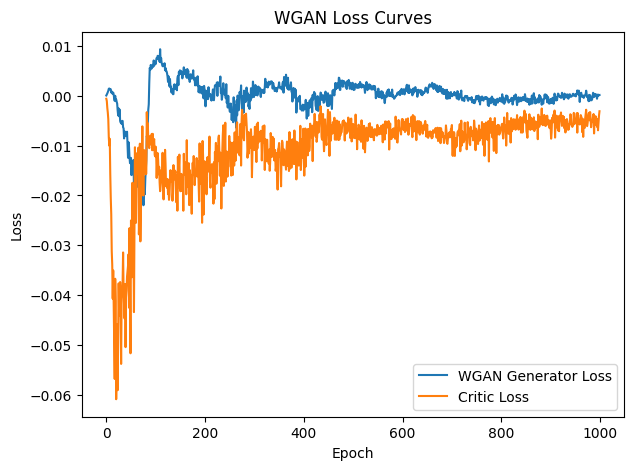

In [104]:
plt.figure(figsize=(7,5))

plt.plot(wgan_g_losses, label='WGAN Generator Loss')
plt.plot(critic_losses, label='Critic Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN Loss Curves")

plt.legend()
plt.show()

**Generate Synthetic Samples**

In [105]:
noise = tf.random.normal([num_samples_to_generate, latent_dim])

synthetic_wgan = wgan_generator(noise).numpy()

print(synthetic_wgan.shape)

(145, 30)


In [106]:
synthetic_wgan_labels = np.ones(num_samples_to_generate)

X_balanced_wgan = np.vstack([X_scaled, synthetic_wgan])
y_balanced_wgan = np.concatenate([y, synthetic_wgan_labels])

print(X_balanced_wgan.shape)
print(y_balanced_wgan.shape)

(714, 30)
(714,)


In [107]:
pd.Series(y_balanced_wgan).value_counts()

,count
1.0,357
0.0,357


**Classification**

In [108]:
X_train_wgan, X_test_wgan, y_train_wgan, y_test_wgan = train_test_split(
    X_balanced_wgan,
    y_balanced_wgan,
    test_size=0.2,
    random_state=42
)

print(X_train_wgan.shape)

(571, 30)


In [109]:
# Classifier on balanced data using WGAN

clf_wgan = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    random_state=42
)

clf_wgan.fit(X_train_wgan, y_train_wgan)

y_pred_wgan = clf_wgan.predict(X_test_wgan)

print("Balanced Dataset with WGAN Results")
print(classification_report(y_test_wgan, y_pred_wgan))

Balanced Dataset with WGAN Results
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98        69
         1.0       0.97      0.99      0.98        74

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



# **Visualization**

**Visualization and Performance Comparison**

Different visualizations were created to compare the performance of the models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix

AUC-ROC Curve

AUC-ROC Original:    0.9948
AUC-ROC Vanilla GAN: 0.9971
AUC-ROC WGAN:        0.9975


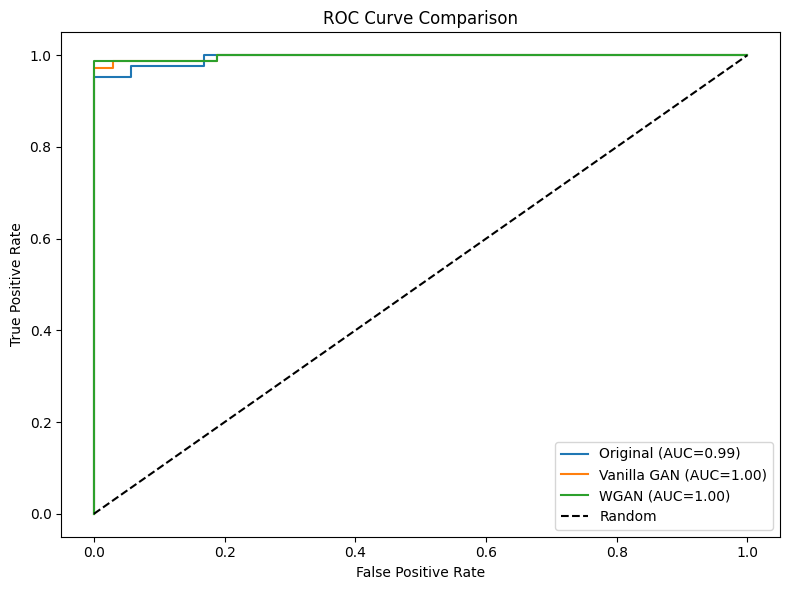

In [110]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, roc_curve
import matplotlib.pyplot as plt

# AUC-ROC


# Original
auc_orig = roc_auc_score(y_test_orig,
           clf_orig.predict_proba(X_test_orig)[:,1])

# Vanilla GAN
auc_bal = roc_auc_score(y_test_bal,
          clf_bal.predict_proba(X_test_bal)[:,1])

# WGAN
auc_wgan = roc_auc_score(y_test_wgan,
           clf_wgan.predict_proba(X_test_wgan)[:,1])

print(f"AUC-ROC Original:    {auc_orig:.4f}")
print(f"AUC-ROC Vanilla GAN: {auc_bal:.4f}")
print(f"AUC-ROC WGAN:        {auc_wgan:.4f}")


#  ROC Curves
plt.figure(figsize=(8, 6))

for clf, X_t, y_t, label in [
    (clf_orig,  X_test_orig, y_test_orig, f'Original (AUC={auc_orig:.2f})'),
    (clf_bal,   X_test_bal,  y_test_bal,  f'Vanilla GAN (AUC={auc_bal:.2f})'),
    (clf_wgan,  X_test_wgan, y_test_wgan, f'WGAN (AUC={auc_wgan:.2f})')
]:
    fpr, tpr, _ = roc_curve(y_t, clf.predict_proba(X_t)[:,1])
    plt.plot(fpr, tpr, label=label)

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

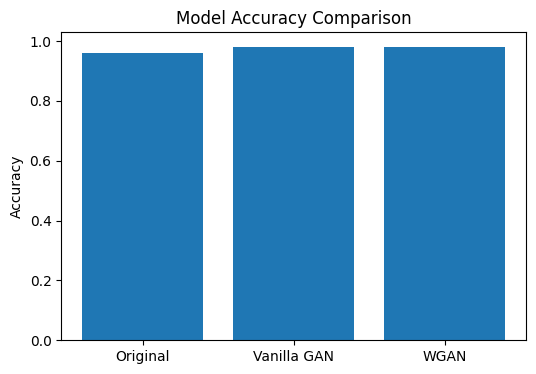

In [111]:
import matplotlib.pyplot as plt

models = ['Original', 'Vanilla GAN', 'WGAN']
accuracy = [0.96, 0.98, 0.98]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [112]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

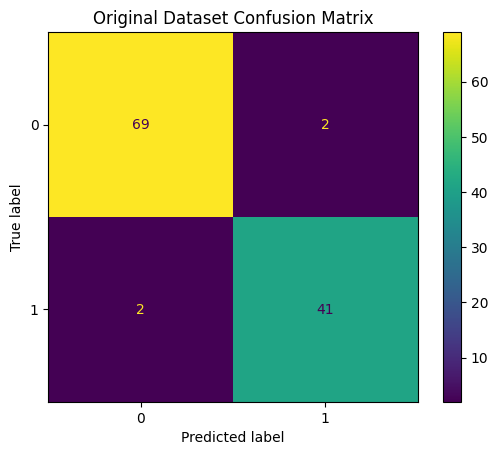

In [113]:
cm_orig = confusion_matrix(y_test_orig, y_pred_orig)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_orig)

disp.plot()
plt.title("Original Dataset Confusion Matrix")
plt.show()

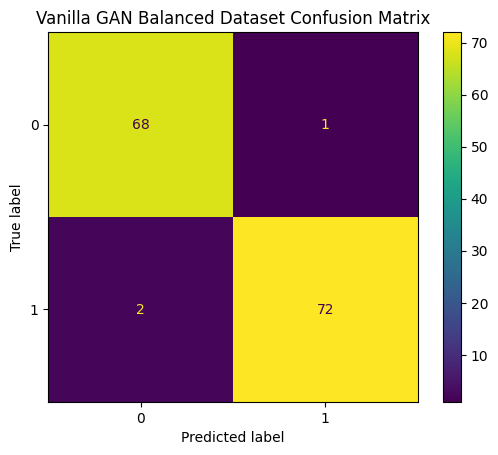

In [114]:
cm_vanilla = confusion_matrix(y_test_bal, y_pred_bal)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_vanilla)

disp.plot()

plt.title("Vanilla GAN Balanced Dataset Confusion Matrix")

plt.show()

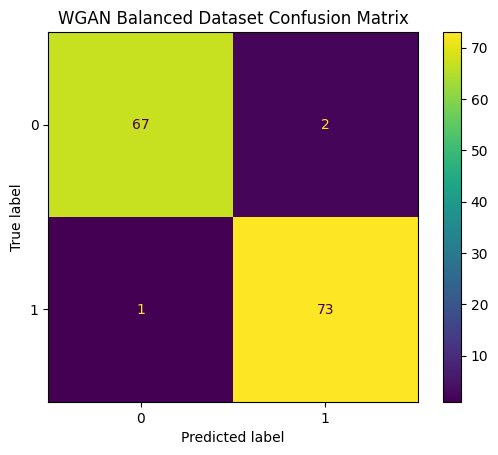

In [115]:
cm_wgan = confusion_matrix(y_test_wgan, y_pred_wgan)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_wgan)

disp.plot()
plt.title("WGAN Balanced Dataset Confusion Matrix")
plt.show()

Recall Comparison

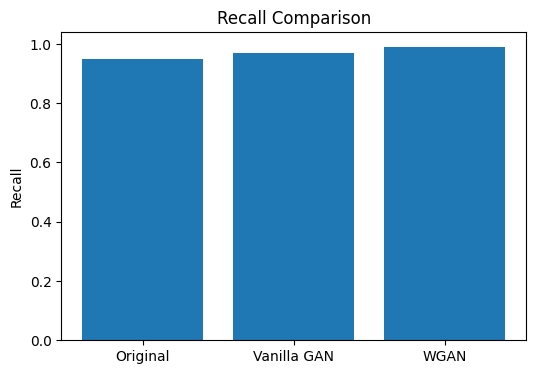

In [116]:
models = ['Original', 'Vanilla GAN', 'WGAN']

recall_scores = [0.95, 0.97, 0.99]

plt.figure(figsize=(6,4))
plt.bar(models, recall_scores)

plt.ylabel("Recall")
plt.title("Recall Comparison")

plt.show()

F1-score Comparison

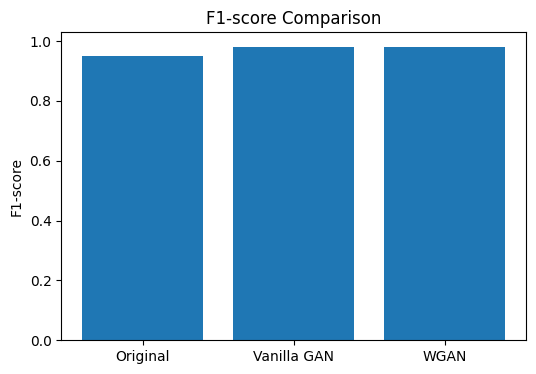

In [117]:
models = ['Original', 'Vanilla GAN', 'WGAN']

f1_scores = [0.95, 0.98, 0.98]

plt.figure(figsize=(6,4))
plt.bar(models, f1_scores)

plt.ylabel("F1-score")
plt.title("F1-score Comparison")

plt.show()

Precision Comparison

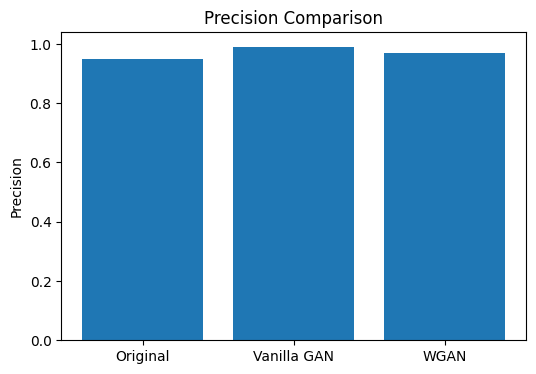

In [118]:
models = ['Original', 'Vanilla GAN', 'WGAN']

precision_scores = [0.95, 0.99, 0.97]

plt.figure(figsize=(6,4))
plt.bar(models, precision_scores)

plt.ylabel("Precision")
plt.title("Precision Comparison")

plt.show()

**The results show that balancing the dataset using GAN-based approaches improved classification performance. WGAN achieved the best overall performance due to its stable training and ability to generate higher-quality synthetic samples**